In [137]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import csv

## Setup:
We will be working with 100 SKUs, 1 store setup. This is because our data only support 1 layer of store, and we limit the number of SKUs to 100 to keep things simple.

The original code runs on data of about 3 years. We will use 3 year for our case.

## Data preparation:

Looking at the `sku100.single_store.standard.yml` file, we need to transform the Walmart data into the same template with these files:
- sku_list: ReplenishmentEnv/data/sku2778/sku100.sku_list.csv
- procurement_cost: ReplenishmentEnv/data/sku2778/sku2778.store2.selling_price.csv
- selling_price: ReplenishmentEnv/data/sku2778/sku2778.store1.selling_price.csv
- demand: ReplenishmentEnv/data/sku2778/sku2778.demand.csv
- static_data: ReplenishmentEnv/data/sku2778/sku2778.store1.info.csv

### SKU list
Looking at the raw demand data, we can see that it's very dense - there are demands for almost every day. But the Walmart data is rather sparse - there are many days with demand = 0.

When exploring the Walmart file in Excel, I realized `store = CA_3` and `cat_id = FOODS` has most dense demand. Therefore that's what we're going to work with.

To further narrow down the SKU list, the code below looks for SKUs with no periods of 7 days without any demand.

In [2]:
df = pd.read_csv("sales_train_evaluation.csv")

ca3_food_df = df.query('store_id == "CA_3" and cat_id == "FOODS"')

ca3_food_df.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
7710,FOODS_1_001_CA_3_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_3,CA,1,2,1,1,...,1,2,2,0,0,1,0,3,2,2
7711,FOODS_1_002_CA_3_evaluation,FOODS_1_002,FOODS_1,FOODS,CA_3,CA,1,0,1,2,...,1,1,2,0,0,0,0,1,2,0
7712,FOODS_1_003_CA_3_evaluation,FOODS_1_003,FOODS_1,FOODS,CA_3,CA,1,1,1,3,...,1,0,3,2,4,0,0,0,0,3
7713,FOODS_1_004_CA_3_evaluation,FOODS_1_004,FOODS_1,FOODS,CA_3,CA,0,0,0,0,...,16,12,9,8,8,12,7,7,11,19
7714,FOODS_1_005_CA_3_evaluation,FOODS_1_005,FOODS_1,FOODS,CA_3,CA,10,3,2,10,...,0,6,1,4,0,3,1,11,2,1


In [3]:
# Define 3-year window (approx 3*365 = 1095 days)
max_cnt = 0
best_start = None
best_consistent_items = []

for start_day in range(1, 1941 - 1095):
    end_day = start_day + 1095  # define end of 3-year window

    # Extract relevant day columns
    day_cols = [f'd_{i}' for i in range(start_day, end_day + 1)]
    window_df = ca3_food_df[['id'] + day_cols]

    # Check for long inactive gaps (7 consecutive zero days, updated rolling syntax)
    zero_matrix = (window_df[day_cols] == 0).astype(int)
    rolling_zero = zero_matrix.T.rolling(window=7).sum().T
    long_gap = (rolling_zero == 7).any(axis=1)

    # Filter consistent items
    consistent_items = window_df[~long_gap]['id'].unique()

    if len(consistent_items) > max_cnt:
        max_cnt = len(consistent_items)
        best_start = start_day
        best_consistent_items = consistent_items[:]

print(f"Best window starts at d_{best_start}, with {max_cnt} continuous items.")



Best window starts at d_836, with 100 continuous items.


Looking at the `calendar.csv` file, `d_836` corresponds to `2013-05-13`.

Our end date is `d_836` + 1095 days, which is `d_1931`, or `2016-05-12`. 

In [ ]:
# Write the output to a file
best_consistent_items = best_consistent_items[:100] # this step is not needed since we have exactly 100 SKUs, I just put it here for clarity

with open('../processed/wm1/sku100.sku_list.foods.ca3.highest_demand.csv', 'w') as file:
    writer = csv.writer(file)
    writer.writerow(['SKU'])
    for item in best_consistent_items:
        writer.writerow([item])

### Procurement cost and selling price

We have selling price data from Walmart, but we don't have procurement cost. We will make the assumption that procurement cost is 70% of selling price.

Now we need to transform the weekly sales price from `sell_prices.csv` to the same format as `sku2778.store2.selling_price.csv`, and to get the procurement cost we apply a 70% reduction.

In [88]:
wm_price = pd.read_csv('sell_prices.csv')
wm_price

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26
...,...,...,...,...
6841116,WI_3,FOODS_3_827,11617,1.00
6841117,WI_3,FOODS_3_827,11618,1.00
6841118,WI_3,FOODS_3_827,11619,1.00
6841119,WI_3,FOODS_3_827,11620,1.00


In [89]:
calendar = pd.read_csv('calendar.csv')
calendar

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1964,2016-06-15,11620,Wednesday,5,6,2016,d_1965,NaN,NaN,NaN,NaN,0,1,1
1965,2016-06-16,11620,Thursday,6,6,2016,d_1966,NaN,NaN,NaN,NaN,0,0,0
1966,2016-06-17,11620,Friday,7,6,2016,d_1967,NaN,NaN,NaN,NaN,0,0,0
1967,2016-06-18,11621,Saturday,1,6,2016,d_1968,NaN,NaN,NaN,NaN,0,0,0


In [90]:
store = 'CA_3'
items = best_consistent_item_ids
start_d, end_d = 'd_836', 'd_1931'

start_d_num = int(start_d.split('_')[1])
end_d_num = int(end_d.split('_')[1])

calendar['d_num'] = calendar['d'].str.split('_').str[1].astype(int)

cal = calendar.loc[
    (calendar['d_num'] >= start_d_num) & (calendar['d_num'] <= end_d_num),
    ['date', 'wm_yr_wk', 'd']
].copy()

cal['Date'] = pd.to_datetime(cal['date']).dt.strftime('%Y/%m/%d')

wm = wm_price.query("store_id == @store and item_id in @items")[['item_id', 'wm_yr_wk', 'sell_price']]

cal['wm_yr_wk'] = cal['wm_yr_wk'].astype(int)
wm['wm_yr_wk'] = wm['wm_yr_wk'].astype(int)
daily = cal.merge(wm, on='wm_yr_wk', how='left')

wide = (
    daily.pivot_table(index='Date', columns='item_id', values='sell_price', aggfunc='first')
    .sort_index()
)

cols = [c for c in items if c in wide.columns]
wide = wide[cols]

selling_price = wide.reset_index()
selling_price.columns = ['Date'] + [x + '_CA_3_evaluation' for x in selling_price.columns[1:]]

procurement_cost = selling_price.copy()

# Set the price to be 70% of current values
procurement_cost.iloc[:, 1:] = procurement_cost.iloc[:, 1:] * 0.7

procurement_cost

,Date,FOODS_1_018_CA_3_evaluation,FOODS_1_021_CA_3_evaluation,FOODS_1_023_CA_3_evaluation,FOODS_1_046_CA_3_evaluation,FOODS_1_082_CA_3_evaluation,FOODS_1_085_CA_3_evaluation,FOODS_1_087_CA_3_evaluation,FOODS_1_099_CA_3_evaluation,FOODS_1_139_CA_3_evaluation,...,FOODS_3_714_CA_3_evaluation,FOODS_3_721_CA_3_evaluation,FOODS_3_741_CA_3_evaluation,FOODS_3_752_CA_3_evaluation,FOODS_3_756_CA_3_evaluation,FOODS_3_765_CA_3_evaluation,FOODS_3_775_CA_3_evaluation,FOODS_3_792_CA_3_evaluation,FOODS_3_819_CA_3_evaluation,FOODS_3_820_CA_3_evaluation
0,2013/05/13,0.686,0.686,3.661,0.686,0.686,0.686,3.661,0.686,0.686,...,1.036,1.386,0.875,0.140,1.876,2.016,2.436,0.7,1.386,1.386
1,2013/05/14,0.686,0.686,3.661,0.686,0.686,0.686,3.661,0.686,0.686,...,1.036,1.386,0.875,0.140,1.876,2.016,2.436,0.7,1.386,1.386
2,2013/05/15,0.686,0.686,3.661,0.686,0.686,0.686,3.661,0.686,0.686,...,1.036,1.386,0.875,0.140,1.876,2.016,2.436,0.7,1.386,1.386
3,2013/05/16,0.686,0.686,3.661,0.686,0.686,0.686,3.661,0.686,0.686,...,1.036,1.386,0.875,0.140,1.876,2.016,2.436,0.7,1.386,1.386
4,2013/05/17,0.686,0.686,3.661,0.686,0.686,0.686,3.661,0.686,0.686,...,1.036,1.386,0.875,0.140,1.876,2.016,2.436,0.7,1.386,1.386
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1091,2016/05/08,0.686,0.686,3.948,0.686,0.686,0.686,3.948,0.686,0.686,...,1.106,1.386,0.945,0.175,1.750,2.100,2.646,0.7,1.386,1.386
1092,2016/05/09,0.686,0.686,3.948,0.686,0.686,0.686,3.948,0.686,0.686,...,1.106,1.386,0.945,0.175,1.750,2.100,2.646,0.7,1.386,1.386
1093,2016/05/10,0.686,0.686,3.948,0.686,0.686,0.686,3.948,0.686,0.686,...,1.106,1.386,0.945,0.175,1.750,2.100,2.646,0.7,1.386,1.386
1094,2016/05/11,0.686,0.686,3.948,0.686,0.686,0.686,3.948,0.686,0.686,...,1.106,1.386,0.945,0.175,1.750,2.100,2.646,0.7,1.386,1.386


In [91]:
selling_price

,Date,FOODS_1_018_CA_3_evaluation,FOODS_1_021_CA_3_evaluation,FOODS_1_023_CA_3_evaluation,FOODS_1_046_CA_3_evaluation,FOODS_1_082_CA_3_evaluation,FOODS_1_085_CA_3_evaluation,FOODS_1_087_CA_3_evaluation,FOODS_1_099_CA_3_evaluation,FOODS_1_139_CA_3_evaluation,...,FOODS_3_714_CA_3_evaluation,FOODS_3_721_CA_3_evaluation,FOODS_3_741_CA_3_evaluation,FOODS_3_752_CA_3_evaluation,FOODS_3_756_CA_3_evaluation,FOODS_3_765_CA_3_evaluation,FOODS_3_775_CA_3_evaluation,FOODS_3_792_CA_3_evaluation,FOODS_3_819_CA_3_evaluation,FOODS_3_820_CA_3_evaluation
0,2013/05/13,0.98,0.98,5.23,0.98,0.98,0.98,5.23,0.98,0.98,...,1.48,1.98,1.25,0.20,2.68,2.88,3.48,1.0,1.98,1.98
1,2013/05/14,0.98,0.98,5.23,0.98,0.98,0.98,5.23,0.98,0.98,...,1.48,1.98,1.25,0.20,2.68,2.88,3.48,1.0,1.98,1.98
2,2013/05/15,0.98,0.98,5.23,0.98,0.98,0.98,5.23,0.98,0.98,...,1.48,1.98,1.25,0.20,2.68,2.88,3.48,1.0,1.98,1.98
3,2013/05/16,0.98,0.98,5.23,0.98,0.98,0.98,5.23,0.98,0.98,...,1.48,1.98,1.25,0.20,2.68,2.88,3.48,1.0,1.98,1.98
4,2013/05/17,0.98,0.98,5.23,0.98,0.98,0.98,5.23,0.98,0.98,...,1.48,1.98,1.25,0.20,2.68,2.88,3.48,1.0,1.98,1.98
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1091,2016/05/08,0.98,0.98,5.64,0.98,0.98,0.98,5.64,0.98,0.98,...,1.58,1.98,1.35,0.25,2.50,3.00,3.78,1.0,1.98,1.98
1092,2016/05/09,0.98,0.98,5.64,0.98,0.98,0.98,5.64,0.98,0.98,...,1.58,1.98,1.35,0.25,2.50,3.00,3.78,1.0,1.98,1.98
1093,2016/05/10,0.98,0.98,5.64,0.98,0.98,0.98,5.64,0.98,0.98,...,1.58,1.98,1.35,0.25,2.50,3.00,3.78,1.0,1.98,1.98
1094,2016/05/11,0.98,0.98,5.64,0.98,0.98,0.98,5.64,0.98,0.98,...,1.58,1.98,1.35,0.25,2.50,3.00,3.78,1.0,1.98,1.98


In [ ]:
procurement_cost.to_csv('../processed/wm1/sku100.procurement_cost.csv', index=False)
selling_price.to_csv('../processed/wm1/sku100.selling_price.csv', index=False)

### Demand

We transform the data into the same format as before.

In [112]:
demand = pd.read_csv('sales_train_evaluation.csv')
demand = demand.query('id in @best_consistent_items')
demand = demand[['id'] + ['d_' + str(x) for x in range(start_d_num, end_d_num+1)]]
demand

,id,d_836,d_837,d_838,d_839,d_840,d_841,d_842,d_843,d_844,...,d_1922,d_1923,d_1924,d_1925,d_1926,d_1927,d_1928,d_1929,d_1930,d_1931
7726,FOODS_1_018_CA_3_evaluation,4,3,5,1,6,8,6,4,5,...,13,5,13,14,18,12,13,13,3,10
7729,FOODS_1_021_CA_3_evaluation,0,2,1,0,2,0,2,1,1,...,0,3,0,0,0,2,0,2,0,0
7731,FOODS_1_023_CA_3_evaluation,1,0,2,11,4,5,0,0,7,...,5,6,5,7,2,1,2,1,5,5
7754,FOODS_1_046_CA_3_evaluation,4,3,2,3,2,5,1,1,4,...,5,2,2,2,6,3,5,1,1,1
7790,FOODS_1_082_CA_3_evaluation,0,0,0,4,3,5,3,2,2,...,4,1,0,5,2,0,0,0,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9084,FOODS_3_765_CA_3_evaluation,1,0,1,3,2,0,0,0,0,...,5,0,4,1,1,1,0,1,0,1
9094,FOODS_3_775_CA_3_evaluation,0,3,0,0,1,2,4,0,2,...,0,1,1,1,0,5,1,2,0,1
9111,FOODS_3_792_CA_3_evaluation,1,12,0,10,0,7,16,9,8,...,7,3,3,1,2,2,1,3,1,4
9138,FOODS_3_819_CA_3_evaluation,3,3,2,2,7,5,14,2,5,...,0,7,0,2,6,2,2,1,2,3


In [ ]:
calendar_subset = calendar[['d', 'date']].copy()
calendar_subset['date'] = pd.to_datetime(calendar_subset['date']).dt.strftime('%Y/%m/%d')
d_to_date = dict(zip(calendar_subset['d'], calendar_subset['date']))
demand = demand.rename(columns=d_to_date).transpose()
demand.columns = demand.iloc[0]
demand = demand.drop(demand.index[0])
demand.index.name = "Date"
demand.reset_index(inplace=True)

In [117]:
demand

id,Date,FOODS_1_018_CA_3_evaluation,FOODS_1_021_CA_3_evaluation,FOODS_1_023_CA_3_evaluation,FOODS_1_046_CA_3_evaluation,FOODS_1_082_CA_3_evaluation,FOODS_1_085_CA_3_evaluation,FOODS_1_087_CA_3_evaluation,FOODS_1_099_CA_3_evaluation,FOODS_1_139_CA_3_evaluation,...,FOODS_3_714_CA_3_evaluation,FOODS_3_721_CA_3_evaluation,FOODS_3_741_CA_3_evaluation,FOODS_3_752_CA_3_evaluation,FOODS_3_756_CA_3_evaluation,FOODS_3_765_CA_3_evaluation,FOODS_3_775_CA_3_evaluation,FOODS_3_792_CA_3_evaluation,FOODS_3_819_CA_3_evaluation,FOODS_3_820_CA_3_evaluation
0,2013/05/13,4,0,1,4,0,3,0,1,8,...,26,2,8,28,10,1,0,1,3,2
1,2013/05/14,3,2,0,3,0,6,1,0,4,...,37,2,21,76,1,0,3,12,3,1
2,2013/05/15,5,1,2,2,0,4,2,1,6,...,23,1,18,26,0,1,0,0,2,0
3,2013/05/16,1,0,11,3,4,6,5,1,8,...,14,4,3,10,3,3,0,10,2,2
4,2013/05/17,6,2,4,2,3,9,7,8,13,...,21,5,0,21,3,2,1,0,7,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1091,2016/05/08,12,2,1,3,0,7,1,7,0,...,35,13,7,12,22,1,5,2,2,2
1092,2016/05/09,13,0,2,5,0,5,2,4,0,...,36,0,15,26,18,0,1,1,2,3
1093,2016/05/10,13,2,1,1,0,6,3,10,2,...,29,0,6,10,7,1,2,3,1,5
1094,2016/05/11,3,0,5,1,3,5,5,5,0,...,23,1,5,8,17,0,0,1,2,2


In [ ]:
demand.to_csv('../processed/wm1/sku100.demand.csv', index=False)

### Static data

The data includes initial stock and vlt (vendor lead time).

We assume initial stock to be first week demand.

For vlt, let's look at the data

In [131]:
store_data = pd.read_csv('../../../data/sku2778/sku2778.store1.info.csv')
store_data

,SKU,init_stock,vlt
0,SKU0,9,1
1,SKU1,306,1
2,SKU2,12,1
3,SKU3,112,3
4,SKU4,2,3
...,...,...,...
2773,SKU2773,26,1
2774,SKU2774,80,1
2775,SKU2775,10,1
2776,SKU2776,0,1


<Axes: >

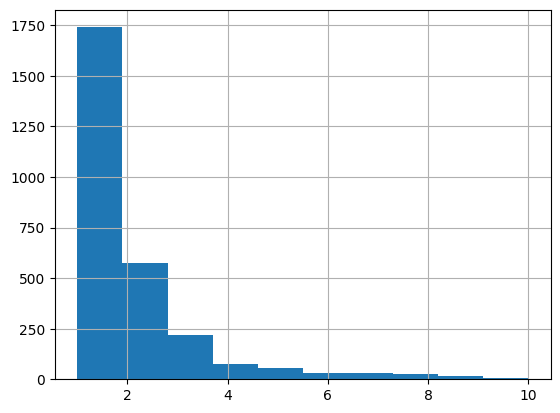

In [133]:
store_data['vlt'].hist()

The graph above follows log-normal distribution. We will generate it that way.

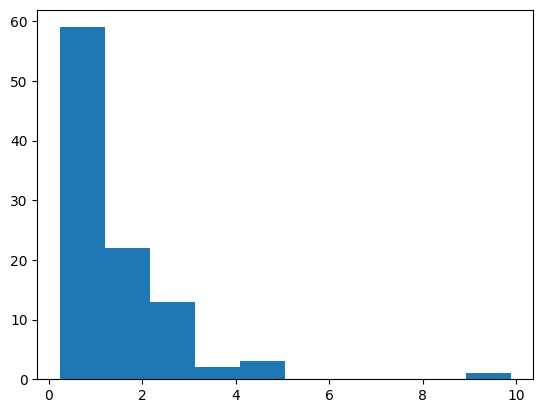

In [144]:
data = np.random.lognormal(mean=0.1, sigma=0.7, size=100)
_ = plt.hist(data)

In [150]:
sku_cols = [c for c in demand.columns if c not in ['id', 'Date']]
init_stock = demand[sku_cols].head(7).sum(axis=0)
vlt = np.ceil(np.random.lognormal(mean=0.1, sigma=0.7, size=len(sku_cols))).astype(int)

store_info = pd.DataFrame({
    'SKU': sku_cols,
    'init_stock': init_stock.values,
    'vlt': vlt
})

In [151]:
store_info

,SKU,init_stock,vlt
0,FOODS_1_018_CA_3_evaluation,33,1
1,FOODS_1_021_CA_3_evaluation,7,3
2,FOODS_1_023_CA_3_evaluation,23,4
3,FOODS_1_046_CA_3_evaluation,20,1
4,FOODS_1_082_CA_3_evaluation,15,3
...,...,...,...
95,FOODS_3_765_CA_3_evaluation,7,1
96,FOODS_3_775_CA_3_evaluation,10,1
97,FOODS_3_792_CA_3_evaluation,46,2
98,FOODS_3_819_CA_3_evaluation,36,1


In [ ]:
store_info.to_csv('../processed/wm1/sku100.store_info.csv', index=False)